In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
cation_pka=pd.read_excel("../data/pk_cation.xlsx")
anion_pka=pd.read_excel("../data/pkaanion.xlsx")
print(df.shape)
print(cation_pka.shape)
print(anion_pka.shape)

(5349, 444)
(77, 2)
(80, 2)


In [3]:
df["IL NAME"] = (
    
    df["CATION NAME"].astype(str) +
    " " +
    df["ANION NAME"].astype(str) )

In [4]:
ffv=pd.read_csv("../outputs/tables/unique_ionic_liquids_with_ffv.csv")

In [5]:
df = df.merge(ffv[["IL NAME", "FFV"]],on="IL NAME",how="left")

In [6]:
cation_pka=cation_pka.rename(columns={ "CATION": 'CATION NAME' })

In [7]:
anion_pka=anion_pka.rename(columns={"Anion":"ANION NAME"})

In [8]:
df = pd.merge(df,cation_pka,on="CATION NAME",how="left")

In [9]:
df = pd.merge(df,anion_pka,on="ANION NAME",how="left")

In [10]:
df["CATION_pKa"].isnull().sum()

np.int64(0)

In [11]:
df["Anion_pKa"].isnull().sum()

np.int64(0)

In [12]:
df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]

C:\Users\BIT\AppData\Local\Temp\ipykernel_18488\3233356666.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]


In [13]:
df["Delta_pKa"].describe()

count    5349.000000
mean       14.860804
std         6.282438
min        -4.600000
25%         8.600000
50%        17.500000
75%        20.800000
max        27.500000
Name: Delta_pKa, dtype: float64

In [14]:
df[df["Delta_pKa"] < 2][
    [
        "CATION NAME",
        "ANION NAME",
        "CATION_pKa",
        "Anion_pKa",
        "Delta_pKa"
    ]
]

,CATION NAME,ANION NAME,CATION_pKa,Anion_pKa,Delta_pKa
16,triethylenetetrammonium,piperazine,9.9,9.80,0.10
17,triethylenetetrammonium,imidazolate,9.9,14.50,-4.60
19,triethylenetetrammonium,"1,2,4-triazolate",9.9,10.20,-0.30
36,trihexyl(tetradecyl)phosphonium,phenolate,8.5,9.95,-1.45
37,trihexyl(tetradecyl)phosphonium,p-methylphenolate,8.5,10.30,-1.80
38,trihexyl(tetradecyl)phosphonium,p-chlorophenolate,8.5,9.38,-0.88
39,trihexyl(tetradecyl)phosphonium,p-trifluoromethylphenolate,8.5,8.45,0.05
40,trihexyl(tetradecyl)phosphonium,p-nitrophenolate,8.5,7.15,1.35
41,"N, N-dimethyl-1,3-propane diamine",p-fluorophenolate,10.0,9.95,0.05
47,triethyl(octyl)phosphonium,2-cyanopyrrol-1-ide,8.7,10.50,-1.80


In [15]:
known_ffv = df[df["FFV"].notna()].copy()

In [16]:
known_ffv.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_tetrazole', 'An_fr_thiazole', 'An_fr_thiocyan',
       'An_fr_thiophene', 'An_fr_unbrch_alkane', 'An_fr_urea', 'FFV',
       'CATION_pKa', 'Anion_pKa', 'Delta_pKa'],
      dtype='str', length=448)

In [54]:
x=known_ffv[["Temperature (0 C)","Pressure (bar)","Delta_pKa","FFV"]]

In [55]:
y=known_ffv["CO2 capacity (mol CO2/mol IL)"]

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 4) (849, 4) (3392,) (849,)
Train R2: 0.9988
TEST METRICS ARE
R2 : 0.9784
MAE : 0.029
RMSE : 0.0642


In [57]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model,X_train,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.94986795 0.989055   0.95457426 0.98103995 0.97387442 0.97649413
 0.97979331 0.98228103 0.88398119 0.92206764]

Mean CV R2: 0.9593
Std CV R2: 0.0316


In [58]:
corr_df = df[
    [
        "Temperature (0 C)",
        "Pressure (bar)",
        "CATION_pKa",
        "Anion_pKa",
        "Delta_pKa",
        "FFV",
        "CO2 capacity (mol CO2/mol IL)"
    ]
].corr()

corr_df

,Temperature (0 C),Pressure (bar),CATION_pKa,Anion_pKa,Delta_pKa,FFV,CO2 capacity (mol CO2/mol IL)
Temperature (0 C),1.000000,0.361796,-0.057081,-0.037749,0.018297,0.043401,-0.032505
Pressure (bar),0.361796,1.000000,-0.058349,-0.019446,0.000338,-0.085553,0.495167
CATION_pKa,-0.057081,-0.058349,1.000000,0.031821,0.283444,-0.139300,0.098999
Anion_pKa,-0.037749,-0.019446,0.031821,1.000000,-0.949484,-0.115947,-0.000289
Delta_pKa,0.018297,0.000338,0.283444,-0.949484,1.000000,0.071531,0.031360
FFV,0.043401,-0.085553,-0.139300,-0.115947,0.071531,1.000000,-0.074025
CO2 capacity (mol CO2/mol IL),-0.032505,0.495167,0.098999,-0.000289,0.031360,-0.074025,1.000000


In [59]:
import shap

In [63]:
explainer = shap.TreeExplainer(model)

In [64]:
print(shap_values.shape)

(849, 4)


In [62]:
shap_values = explainer.shap_values(X_test)

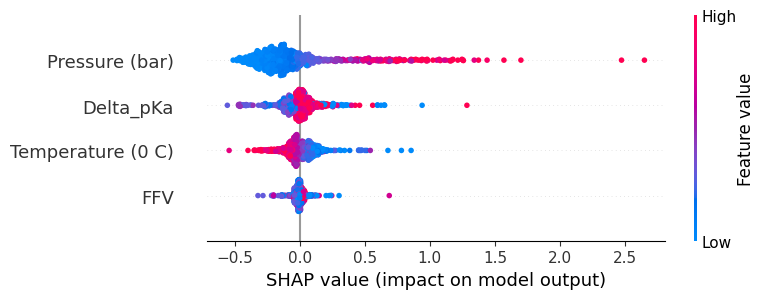

In [65]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
features=pd.read_excel('../data/RF_Top20_Features.xlsx')

In [ ]:
rf_features = features.iloc[:,0].tolist()

In [ ]:
extra_features = [
    "CATION_pKa",
    "Anion_pKa",
    "Delta_pKa",
    "FFV"
]

all_features = list(set(rf_features + extra_features))

In [ ]:
x =known_ffv[all_features]
y=known_ffv["CO2 capacity (mol CO2/mol IL)"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 24) (849, 24) (3392,) (849,)
Train R2: 0.9992
TEST METRICS ARE
R2 : 0.9742
MAE : 0.0247
RMSE : 0.0702


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 24) (849, 24) (3392,) (849,)
Train R2: 0.9992
TEST METRICS ARE
R2 : 0.9742
MAE : 0.0247
RMSE : 0.0702


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model,X_train,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.97583076 0.98789885 0.97767253 0.98895968 0.97969878 0.98986201
 0.97520732 0.98970241 0.95033818 0.97049077]

Mean CV R2: 0.9786
Std CV R2: 0.0115
